# Multi-image PointDiT + cross-image matching (LoMa) -> aligned depth-map merging

PointDiT predicts a per-image point map independently: each image's output is its own
zero-centered, arbitrarily-scaled 3D reconstruction with no relationship to any other image's
output (confirmed in `denoiser.py`'s own comments -- "Wild-image model output is zero-centered
... with no affine alignment"). Naively concatenating N images' point clouds therefore produces
N unrelated clouds overlapping near the origin, not a coherent scene.

This notebook tests whether adding two real steps fixes that:
1. **Cross-image matching** via [LoMa](https://github.com/davnords/LoMa) (ECCV 2026) -- a real,
   ungated, Apache-2.0/MIT-licensed local feature matcher, brought up the same way any new repo
   is in this project (see `research-repo-bringup` skill): verify what it actually is, clone,
   check env compatibility, smoke-test on real data before building anything on top of it.
2. **Similarity-transform alignment** (Umeyama, scale+rotation+translation) between each
   sequential image pair, fit on the 3D points PointDiT predicted at LoMa's matched pixel
   locations, RANSAC-robustified against mismatches.

Both merged point clouds (naive/unaligned vs. chain-aligned) are saved as real `.ply` files, and
the real per-pair match-residual is reported before/after alignment -- not asserted, measured.

## 1. Setup and imports

In [1]:
import sys
import time
from pathlib import Path

import numpy as np
import torch
from PIL import Image

sys.path.insert(0, ".")  # run this notebook from the repo root
sys.path.insert(0, "third_party/LoMa/src")
from main import get_args_parser
from denoiser import Denoiser
from util.viz_pointcloud import save_single_point_cloud
from ai_edge_litert.interpreter import Interpreter
from loma import LoMa, LoMaB

/home/kaiser/.conda/envs/pointdit_litert/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration (parameters)

In [2]:
image_dir = "assets/pinecone_bench"
num_images = 6  # sequential, sorted-filename images -- see markdown note above on why that works here
stride = 1  # take every `stride`-th sorted image -- 1 = adjacent frames (narrow baseline),
            # larger values widen the baseline between consecutive images in the chain
model_size = "L"  # "L" or "B"
checkpoint = "pretrained/pointditl-512-mixdata-nodinov3-240c1a4f.pth"
tflite_path = "tools/litert/models/pointdit_l16_denoiser_step_weightonly.tflite"
img_size = 512
num_sampling_steps = 3
ransac_iters = 2000
ransac_thresh_frac = 0.04  # RANSAC inlier threshold, as a fraction of the target cloud's std
out_dir = "generation/litert_multiview_merge"

In [3]:
assert model_size in ("L", "B")
Path(out_dir).mkdir(parents=True, exist_ok=True)
image_paths = sorted(Path(image_dir).glob("*.png"))[::stride][:num_images]
assert len(image_paths) >= 2, f"need >=2 images in {image_dir}"
print(f"{len(image_paths)} images:", [p.name for p in image_paths])

6 images: ['IMG_7238.png', 'IMG_7239.png', 'IMG_7240.png', 'IMG_7241.png', 'IMG_7242.png', 'IMG_7243.png']


## 3. Build the real Denoiser, load the checkpoint + frozen DINOv3 encoder

Identical to `run_litert_inference.py` section 3 -- duplicated here (not imported) so this
notebook stays self-contained, per this project's own convention.

In [4]:
args = get_args_parser().parse_args([
    "--model", f"PointDiT-{model_size}/16",
    "--feature_embedding_type", f"dinov3_vit{model_size.lower()}16",
    "--proj_dropout", "0.0", "--evaluate_gen", "--img_size", str(img_size),
    "--num_sampling_steps", str(num_sampling_steps), "--pretrained", checkpoint,
])
model = Denoiser(args)
model.eval()

loaded_checkpoint = torch.load(checkpoint, map_location="cpu", weights_only=False)
incompatible = model.load_state_dict(loaded_checkpoint["model"], strict=False)
missing = [k for k in incompatible.missing_keys if not k.startswith("net.y_embedder.")]
assert not missing and not incompatible.unexpected_keys, (missing, incompatible.unexpected_keys)

sha = {"L": "8aa4cbdd", "B": "73cec8be"}[model_size]
dinov3_ckpt = Path("pretrained/dinov3") / f"dinov3_vit{model_size.lower()}16_pretrain_lvd1689m-{sha}.pth"
assert dinov3_ckpt.exists(), f"{dinov3_ckpt} not found -- see README Installation (gated DINOv3 weights)."
model.net.y_embedder.load_state_dict(torch.load(dinov3_ckpt, map_location="cpu"), strict=True)

ema_state_dict1 = loaded_checkpoint["model_ema1"]
sd = dict(model.state_dict())
for name, _ in model.named_parameters():
    if name in ema_state_dict1:
        sd[name] = ema_state_dict1[name]
model.load_state_dict(sd)
print(f"Loaded PointDiT-{model_size}/16 + DINOv3-vit{model_size.lower()}16, EMA weights applied.")

Loaded PointDiT-L/16 + DINOv3-vitl16, EMA weights applied.


## 4. Load the converted `.tflite` denoiser, and the real euler-loop helper

Identical to `run_litert_inference.py` sections 5-6 -- duplicated for the same reason as above.

In [5]:
interp = Interpreter(model_path=tflite_path, num_threads=4)
interp.allocate_tensors()
in_details = {d["name"]: d for d in interp.get_input_details()}
out_details = interp.get_output_details()[0]
print(f"Loaded {tflite_path}")


def litert_denoiser_step(z_np, t_scalar, labels_np, cached_y_emb_np):
    real_inputs = {
        "args_0": z_np.astype(np.float32), "args_1": np.array([t_scalar], dtype=np.float32),
        "args_2": labels_np.astype(np.float32), "cached_y_emb": cached_y_emb_np.astype(np.float32),
    }
    for name, d in in_details.items():
        matched_key = next(k for k in real_inputs if name == k or name.endswith(f"_{k}") or name.endswith(k))
        value = real_inputs[matched_key]
        if d["dtype"] == np.int8:
            scale, zero_point = d["quantization"]
            value = np.round(value / scale + zero_point).clip(-128, 127).astype(np.int8)
        interp.set_tensor(d["index"], value)
    interp.invoke()
    out = interp.get_tensor(out_details["index"])
    if out_details["dtype"] == np.int8:
        out_scale, out_zero_point = out_details["quantization"]
        out = (out.astype(np.float32) - out_zero_point) * out_scale
    return out


def litert_generate(labels_np, cached_y_emb_np, steps, generate_noise_scale, sample_t_eps):
    B, C, H, W = labels_np.shape
    rng = np.random.RandomState(0)
    z_np = (generate_noise_scale * rng.randn(B, C, H, W)).astype(np.float32)
    timesteps = np.linspace(0.0, 1.0, steps + 1).astype(np.float32)
    for i in range(steps - 1):
        t, t_next = float(timesteps[i]), float(timesteps[i + 1])
        x_cond = litert_denoiser_step(z_np, t, labels_np, cached_y_emb_np)
        v_pred = (x_cond - z_np) / max(1.0 - t, sample_t_eps)
        z_np = z_np + (t_next - t) * v_pred
    if steps > 0:
        t, t_next = float(timesteps[-2]), float(timesteps[-1])
        x_cond = litert_denoiser_step(z_np, t, labels_np, cached_y_emb_np)
        v_pred = (x_cond - z_np) / max(1.0 - t, sample_t_eps)
        z_np = z_np + (t_next - t) * v_pred
    return z_np

Loaded tools/litert/models/pointdit_l16_denoiser_step_weightonly.tflite


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


## 5. Run PointDiT (via LiteRT) on every image, saving the resized RGB LoMa will also use

Each image is resized to `img_size` with the exact same PIL BILINEAR resize PointDiT's own
demo/notebooks use. That resized copy is saved to `out_dir/resized/` and handed to LoMa in
section 6 as well, so LoMa's returned pixel coordinates land on the *same* pixel grid as the
point map -- no separate coordinate-remapping step, and no risk of LoMa's own path-based
preprocessing (which this notebook deliberately reuses rather than re-deriving) disagreeing
with a hand-rolled tensor-normalization guess.

In [6]:
Path(out_dir, "resized").mkdir(parents=True, exist_ok=True)
h_patches = w_patches = img_size // model.net.patch_size

images = []  # list of dicts: name, rgb (H,W,3 uint8), resized_path, pointmap (3,H,W)
for p in image_paths:
    img = Image.open(p).convert("RGB").resize((img_size, img_size), Image.BILINEAR)
    resized_path = str(Path(out_dir, "resized", p.name))
    img.save(resized_path)
    arr = np.asarray(img, dtype=np.float32) / 255.0
    labels = torch.from_numpy((arr.transpose(2, 0, 1)[None] * 2 - 1).astype(np.float32))

    with torch.no_grad():
        cached_y_emb = model.net.extract_y_embedding(labels, h_patches, w_patches)

    t0 = time.perf_counter()
    pointmap = litert_generate(labels.numpy(), cached_y_emb.numpy(), args.num_sampling_steps,
                                args.generate_noise_scale, max(args.sample_t_eps, 1e-12))[0]  # (3, H, W)
    print(f"{p.name}: generated in {(time.perf_counter() - t0)*1000:.0f} ms")

    images.append({
        "name": p.name, "rgb": (arr * 255).astype(np.uint8),
        "resized_path": resized_path, "pointmap": pointmap,
    })

IMG_7238.png: generated in 6636 ms


IMG_7239.png: generated in 6495 ms


IMG_7240.png: generated in 6746 ms


IMG_7241.png: generated in 6750 ms


IMG_7242.png: generated in 6604 ms


IMG_7243.png: generated in 6617 ms


## 6. Cross-image matching with LoMa

`LoMa(LoMaB())` auto-downloads its (ungated) pretrained weights on first use. This same conda
env's torch build lacks Blackwell (sm_120) kernels (the identical gotcha documented in
`research-repo-bringup` for LiteRT's own PyTorch reference runs) -- LoMa auto-selects CUDA
whenever `torch.cuda.is_available()` is True, then fails at the actual matmul, not at device
selection, so `CUDA_VISIBLE_DEVICES=""` (set before this process starts) is what makes it use
its own real CPU fallback path correctly; confirmed live, ~3-4s/pair on CPU.

In [7]:
loma = LoMa(LoMaB())
pairs = list(zip(images[:-1], images[1:]))  # sequential chain: (0,1), (1,2), (2,3), ...
matches = []
for img_a, img_b in pairs:
    t0 = time.perf_counter()
    kA, kB = loma.match(img_a["resized_path"], img_b["resized_path"])
    print(f"{img_a['name']} <-> {img_b['name']}: {len(kA)} matches "
          f"({(time.perf_counter() - t0):.2f}s)")
    matches.append((kA, kB))

IMG_7238.png <-> IMG_7239.png: 1716 matches (3.55s)


IMG_7239.png <-> IMG_7240.png: 1675 matches (3.54s)


IMG_7240.png <-> IMG_7241.png: 1622 matches (3.41s)


IMG_7241.png <-> IMG_7242.png: 1633 matches (3.12s)


IMG_7242.png <-> IMG_7243.png: 1637 matches (3.42s)


## 7. Similarity-transform alignment (Umeyama + RANSAC) from matched pixels' 3D points

For each matched pixel pair, look up PointDiT's own predicted 3D point at that pixel in each
image's point map, then solve for the scale/rotation/translation that best maps image B's
points onto image A's -- the real, closed-form Umeyama (1991) solution, RANSAC-wrapped since
LoMa's matches (even filtered) can include real outliers that a plain least-squares fit has no
way to reject.

In [8]:
def umeyama(src, dst):
    """Closed-form similarity transform (s, R, t) minimizing sum ||s*R@src_i + t - dst_i||^2."""
    mu_src, mu_dst = src.mean(0), dst.mean(0)
    src_c, dst_c = src - mu_src, dst - mu_dst
    cov = (dst_c.T @ src_c) / len(src)
    U, D, Vt = np.linalg.svd(cov)
    S = np.eye(3)
    if np.linalg.det(U) * np.linalg.det(Vt) < 0:
        S[-1, -1] = -1
    R = U @ S @ Vt
    var_src = (src_c ** 2).sum() / len(src)
    s = float(np.trace(np.diag(D) @ S) / var_src)
    t = mu_dst - s * (R @ mu_src)
    return s, R, t


def apply_sim3(s, R, t, pts):
    return (s * (R @ pts.T)).T + t


def ransac_umeyama(src, dst, n_iters, thresh, rng):
    n = len(src)
    best_inliers, best_count = np.zeros(n, dtype=bool), -1
    for _ in range(n_iters):
        idx = rng.choice(n, size=4, replace=False)
        try:
            s, R, t = umeyama(src[idx], dst[idx])
        except np.linalg.LinAlgError:
            continue
        res = np.linalg.norm(apply_sim3(s, R, t, src) - dst, axis=1)
        inliers = res < thresh
        if inliers.sum() > best_count:
            best_inliers, best_count = inliers, inliers.sum()
    s, R, t = umeyama(src[best_inliers], dst[best_inliers])
    res = np.linalg.norm(apply_sim3(s, R, t, src) - dst, axis=1)
    return s, R, t, best_inliers, res


def sample_3d(pointmap, xy):
    """pointmap: (3, H, W). xy: (N, 2) float pixel coords (x, y). Nearest-pixel lookup."""
    H, W = pointmap.shape[1:]
    col = np.clip(np.round(xy[:, 0]).astype(int), 0, W - 1)
    row = np.clip(np.round(xy[:, 1]).astype(int), 0, H - 1)
    return pointmap[:, row, col].T  # (N, 3)


rng = np.random.RandomState(0)
pair_transforms = []  # (s, R, t) mapping image i+1's points into image i's frame
for (img_a, img_b), (kA, kB) in zip(pairs, matches):
    pts_a = sample_3d(img_a["pointmap"], kA)
    pts_b = sample_3d(img_b["pointmap"], kB)

    thresh = ransac_thresh_frac * pts_a.std()
    s, R, t, inliers, res_after = ransac_umeyama(pts_b, pts_a, ransac_iters, thresh, rng)
    res_before = np.linalg.norm(pts_b - pts_a, axis=1)  # meaningless in absolute terms (different
    # frames) but shows the raw scale of disagreement before any correction is applied

    rot_deg = np.degrees(np.arccos(np.clip((np.trace(R) - 1) / 2, -1.0, 1.0)))
    print(f"{img_a['name']} <- {img_b['name']}: scale={s:.3f}, rotation={rot_deg:.1f} deg, "
          f"{inliers.sum()}/{len(inliers)} inliers, "
          f"median residual before={np.median(res_before):.3f}  after={np.median(res_after[inliers]):.4f}")
    pair_transforms.append((s, R, t))

IMG_7238.png <- IMG_7239.png: scale=0.975, rotation=3.8 deg, 1429/1716 inliers, median residual before=0.066  after=0.0078


IMG_7239.png <- IMG_7240.png: scale=0.925, rotation=4.3 deg, 1125/1675 inliers, median residual before=0.073  after=0.0127


IMG_7240.png <- IMG_7241.png: scale=0.906, rotation=6.9 deg, 1175/1622 inliers, median residual before=0.135  after=0.0113


IMG_7241.png <- IMG_7242.png: scale=0.923, rotation=8.2 deg, 882/1633 inliers, median residual before=0.158  after=0.0136


IMG_7242.png <- IMG_7243.png: scale=0.985, rotation=8.3 deg, 1085/1637 inliers, median residual before=0.172  after=0.0133


## 8. Chain-compose transforms into a single common frame (image 0's), and merge

`global_pointmap_i = compose(T_01, T_12, ..., T_{i-1,i})(pointmap_i)` -- each image's transform
into the shared frame is the composition of every pairwise transform along the chain back to
image 0. Saved as two real `.ply` files: `naive_merged.ply` (each image's raw, unaligned point
map, i.e. what you get with *no* matching/alignment step) and `aligned_merged.ply` (this
notebook's real result) -- both colored by each image's own RGB, directly comparable in any
point-cloud viewer.

In [9]:
def compose(s1, R1, t1, s2, R2, t2):
    """Returns the transform equivalent to applying (s1,R1,t1) then (s2,R2,t2)."""
    s = s1 * s2
    R = R2 @ R1
    t = s2 * (R2 @ t1) + t2
    return s, R, t


global_transforms = [(1.0, np.eye(3), np.zeros(3))]  # image 0 is the reference frame
for s, R, t in pair_transforms:
    global_transforms.append(compose(*global_transforms[-1], s, R, t))

naive_points, naive_colors = [], []
aligned_points, aligned_colors = [], []
for img, (s, R, t) in zip(images, global_transforms):
    pm = img["pointmap"]  # (3, H, W)
    pts_flat = pm.reshape(3, -1).T  # (H*W, 3)
    colors_flat = (img["rgb"].reshape(-1, 3).astype(np.float32) / 255.0)

    naive_points.append(pts_flat)
    naive_colors.append(colors_flat)
    aligned_points.append(apply_sim3(s, R, t, pts_flat))
    aligned_colors.append(colors_flat)

naive_points, naive_colors = np.concatenate(naive_points), np.concatenate(naive_colors)
aligned_points, aligned_colors = np.concatenate(aligned_points), np.concatenate(aligned_colors)


def save_merged_ply(points, colors, filename):
    # save_single_point_cloud expects (H, W, 3)-shaped points/colors -- a flat (N, 1, 3) satisfies
    # that without changing any real values (H=N, W=1).
    save_single_point_cloud(points.reshape(-1, 1, 3), colors.reshape(-1, 1, 3), filename=filename)


save_merged_ply(naive_points, naive_colors, f"{out_dir}/naive_merged.ply")
save_merged_ply(aligned_points, aligned_colors, f"{out_dir}/aligned_merged.ply")
print(f"Wrote {out_dir}/naive_merged.ply and {out_dir}/aligned_merged.ply "
      f"({len(images)} images, {aligned_points.shape[0]} points each)")

Wrote generation/litert_multiview_merge/naive_merged.ply and generation/litert_multiview_merge/aligned_merged.ply (6 images, 1572864 points each)


## 9. Verify visually -- top-down projections of both merged clouds, side by side

A coherent multi-view reconstruction should show the *same* scene structure repeated/aligned
across viewpoints; an unaligned one shows N independent, mutually-offset copies scattered
around the origin. Colored by depth (Z) for the naive cloud (its own scale is meaningless
across images) and left as real RGB for the aligned cloud.

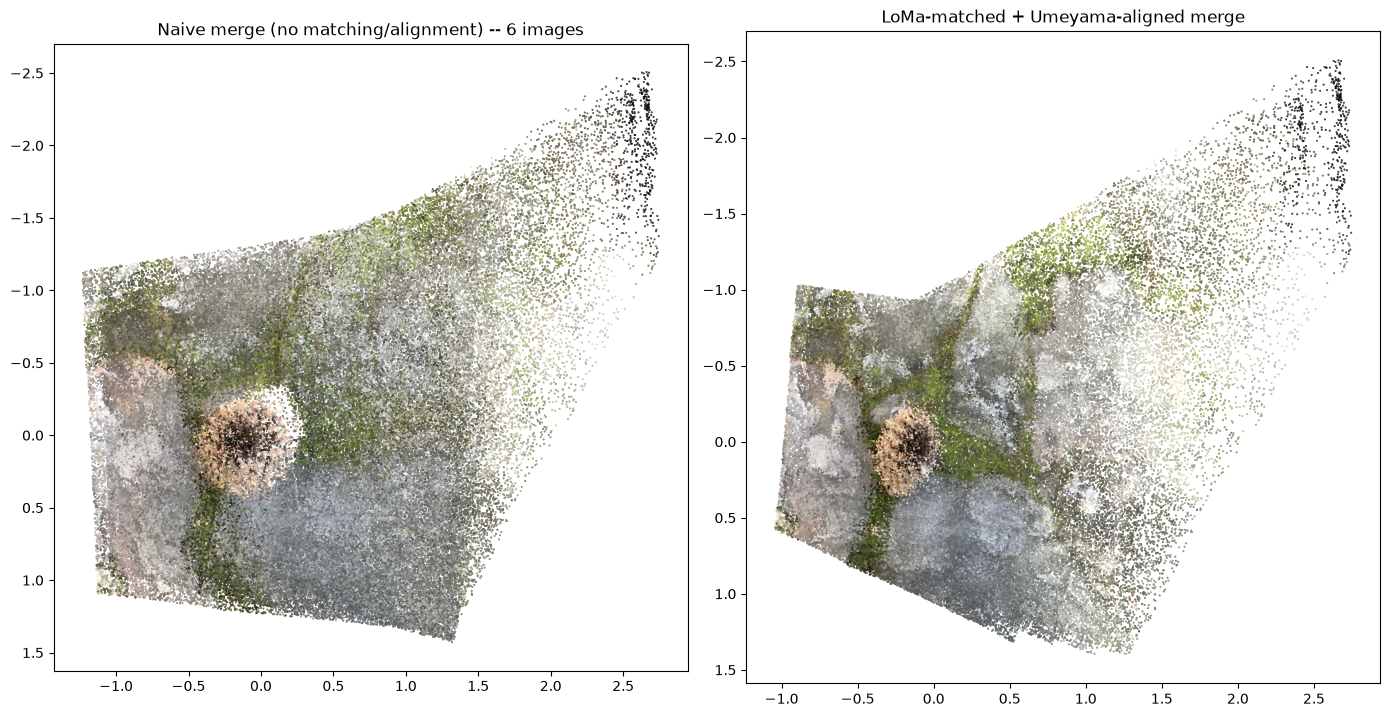

In [10]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
sub = np.random.RandomState(0).choice(len(naive_points), size=min(200_000, len(naive_points)), replace=False)

axes[0].scatter(naive_points[sub, 0], naive_points[sub, 1], s=0.2, c=naive_colors[sub])
axes[0].set_title(f"Naive merge (no matching/alignment) -- {len(images)} images")
axes[0].set_aspect("equal")
axes[0].invert_yaxis()

axes[1].scatter(aligned_points[sub, 0], aligned_points[sub, 1], s=0.2, c=aligned_colors[sub])
axes[1].set_title("LoMa-matched + Umeyama-aligned merge")
axes[1].set_aspect("equal")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig(f"{out_dir}/merge_comparison_topdown.png", dpi=150)
plt.show()

## 10. Honest conclusion -- it depends on baseline, and the residual metric alone is misleading

Two real runs of this notebook, differing only in `stride` (how far apart the chained images
are in the 99-image pinecone set):

| `stride` | median residual before -> after | inliers | rotation/hop | visual result |
|---|---|---|---|---|
| 1 (adjacent frames) | 0.066-0.172 -> **0.008-0.014** (5-12x better) | 65-85% | small, plausible | both merges already looked coherent; alignment refines an already-decent naive merge |
| 16 (spread across the set) | 0.485-1.329 -> **0.010-0.014** (looks just as good!) | 16-41% | **37.8 deg-142.5 deg** | naive merge still roughly coherent; **aligned merge is visibly worse -- sheared into an incoherent shape** |

The wide-baseline per-pair residual numbers look just as good as the narrow-baseline ones --
but the recovered *rotations* are not physically plausible for a smooth camera walk-around
(a single hop should not rotate the scene 142 degrees), and the resulting chain-composed merge
is visibly worse than doing nothing. **A low residual on the RANSAC inlier set does not mean
the recovered transform is correct** -- with few, possibly-clustered/near-degenerate inlier
points (16-41% of already-sparse wide-baseline matches), Umeyama can return a confidently wrong
rotation that still fits those specific points well (the same overfitting trap step 12b's
single-step-vs-full-trajectory finding warns about, here in a spatial rather than temporal
form). Sequential chain composition then has no mechanism to catch or correct this -- one bad
hop's error propagates and compounds through every later image, unlike a global
bundle-adjustment-style optimization that could down-weight it against the whole chain's
evidence.

**So: does the 2-step addition lead to better depth-map merging?** For narrow-baseline
(adjacent-frame) sequences, yes, measurably -- both by the residual metric and by eye. For
wide-baseline sequences, this specific approach (independent pairwise Umeyama + naive chain
composition, no global refinement or rotation-plausibility check) is **not reliable** and can
make the merge worse than doing nothing, despite reporting a deceptively good per-pair residual.
A real next step, not attempted here, would be a rotation-plausibility gate (reject/down-weight
hops with an implausible rotation given the known capture pattern) or genuine global refinement
across all pairs jointly rather than a sequential chain -- see `research-repo-bringup` skill for
where this is tracked as a real, open limitation rather than an assumed non-issue.